## Figure 4D
Due to Trodes tracking error, using LED for head direction is not adviced! Use Eric's gyroscope integrater instead!

In [1]:
### For each remote arm representation, calculate the cos(animal_head, arm)

In [67]:
%reload_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [199]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (figure4_master, save_remote_animal_figure4,
            load_remote_animal_figure4)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

In [10]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name

[21:45:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [340]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'


animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [294]:
proportion = 0.1
use_1d = 1

In [341]:
angles = find_angle_animal(animal, list_of_days_animals[animal],
                           encoding_set_animals[animal],
                           classifier_param_name_animals[animal],
                           proportion, use_1d)

[2025-10-21 21:26:20,064][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2025-10-21 21:26:20,084][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2025-10-21 21:26:20,090][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221026_p0.1_use1d1.pkl':


[21:26:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-21 21:26:26,744][WARNING]: Skipped checksum for file with hash: b46db89b-63e8-05f4-9514-9a0296148a58, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_PN8Z1436QL.nwb
[2025-10-21 21:26:26,769][WARNING]: Skipped checksum for file with hash: b46db89b-63e8-05f4-9514-9a0296148a58, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_PN8Z1436QL.nwb
[2025-10-21 21:26:26,778][WARNING]: Skipped checksum for file with hash: b46db89b-63e8-05f4-9514-9a0296148a58, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_PN8Z1436QL.nwb
[2025-10-21 21:26:32,205][WARNING]: Skipped checksum for file with hash: 8b496b29-6ced-5902-d459-8fe3

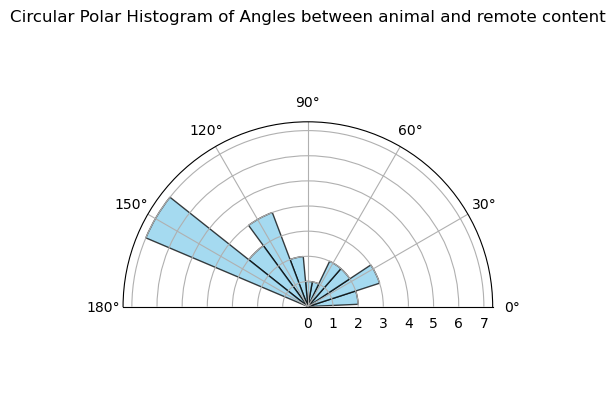

In [342]:
# Create a figure and a polar subplot
fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

# Plot the histogram
# 'bins' controls the number of sectors
# 'alpha' controls the transparency
n, bins, patches = ax.hist(np.deg2rad(angles), bins=10, alpha=0.75, color='skyblue', edgecolor='black')

# Set the title
ax.set_title('Circular Polar Histogram of Angles between animal and remote content')
ax.set_thetamin(0)
ax.set_thetamax(180)

plt.show()
# Display the plot

### Playground

In [76]:
from spyglass.shijiegu.load import load_decode
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd
from spyglass.shijiegu.Analysis_SGU import get_linearization_map
from spyglass.common.common_position import TrackGraph, IntervalLinearizedPosition, IntervalPositionInfo

In [298]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [319]:
info_animal[39]

['lewis20240109_.nwb', '06_Rev2Session3', [28, 28, 28]]

[15:15:16][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:15:16][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [323]:
#arm_identities_animal

In [337]:
ind = 39

In [338]:
print(info_animal[ind], arm_identities_animal[ind])

['lewis20240109_.nwb', '06_Rev2Session3', [28, 28, 28]] [2, 2, 2]


In [327]:
nwb_copy_file_name, session_name, trialID = info_animal[ind]


# 1.
decode = load_decode(nwb_copy_file_name,session_name,'default_decoding_gpu_4armMaze','2Dheadspeed_above_4')
position_axis = np.array(decode.coords['position'])

In [328]:
q = {"nwb_file_name": nwb_copy_file_name,
        "epoch":int(session_name[:2]),
        "proportion":str(proportion)}
    
log_df = ChangeofMind().fetch1_dataframe(q)

[2025-10-21 21:17:04,632][WARNING]: Skipped checksum for file with hash: d5025152-afbe-f71b-4362-e069ee70da9c, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TQBNEQPF6M.nwb


In [339]:
t0, t1 = time_intervals_animal[ind][0]

timestamp_H         1704837183.325913
Home                              1.0
timestamp_O         1704837204.335067
OuterWellIndex                    4.0
rewardNum                         2.0
change_of_mind                   True
CoMMaxProportion             0.828244
initial_choice                    1.0
initial_time        1704837192.212236
proportion_arm1              0.306349
proportion_arm2              0.828244
proportion_arm3                   0.0
proportion_arm4                   0.0
CoMNum_by_time                      3
CoMNum_by_arm                       2
current                           4.0
future_H                          4.0
future_O                          1.0
past                              3.0
past_reward                       2.0
Name: 14, dtype: object

In [330]:
# 2. get decode and animal head direction
position_name = session2position_name(nwb_copy_file_name, session_name)
position_info = (IntervalPositionInfo() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe()
position_info1d = (IntervalLinearizedPosition() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe() #for debug use only

pos2d_subset = select_subset_helper_pd(position_info,(t0,t1))
pos1d_subset = select_subset_helper_pd(position_info1d,(t0,t1))#for debug use only

decode_subset = select_subset_helper(decode,(t0,t1),target_len = len(pos2d_subset),
                                         epsilon = 0.001)
posterior_position_subset = decode_subset.acausal_posterior.sum(dim='state')
if np.abs(len(decode_subset.time) - len(pos2d_subset)) <= 3:
    print("small mismatch")
    minlen = np.min([len(decode_subset.time),len(pos2d_subset)])
    posterior_position_subset = posterior_position_subset[:minlen]
    pos2d_subset = pos2d_subset.iloc[:minlen]
    
max_posterior_1d = np.array(position_axis[posterior_position_subset.argmax(dim = 'position')])

# 3.
max_posterior_2d = np.array([loc1d_to_2d(loc1d, linear_map, nodes) for loc1d in max_posterior_1d])

[2025-10-21 21:17:14,441][WARNING]: Skipped checksum for file with hash: 2bab50d4-5b0d-4135-f8be-48329ef92679, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_2G65EC51OX.nwb
[2025-10-21 21:17:14,463][WARNING]: Skipped checksum for file with hash: 2bab50d4-5b0d-4135-f8be-48329ef92679, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_2G65EC51OX.nwb
[2025-10-21 21:17:14,469][WARNING]: Skipped checksum for file with hash: 2bab50d4-5b0d-4135-f8be-48329ef92679, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_2G65EC51OX.nwb
[21:17:14][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-21 21:17:14,583][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2

small mismatch


In [331]:
# 4. Get animal head direction
head_orientation = np.array(pos2d_subset.head_orientation)
head_orientation_unit = np.hstack((np.cos(head_orientation).reshape((-1,1)),np.sin(head_orientation).reshape((-1,1)))) #unit vector

# Get max_posterior_2d - animal location
animal_location = np.hstack((np.array(pos2d_subset.head_position_x).reshape(-1,1),np.array(pos2d_subset.head_position_y).reshape(-1,1)))
displacement_unit = max_posterior_2d - animal_location
displacement_unit = displacement_unit / np.linalg.norm(displacement_unit, axis = 1).reshape((-1,1))

# finally: return degree
dot_product = [np.dot(head_orientation_unit[i],displacement_unit[i].T) for i in range(displacement_unit.shape[0])]
angle = np.degrees(np.arccos(np.clip(dot_product, -1.0, 1.0)))



In [332]:
angle

array([14.44713613, 14.48218834, 14.51722652, 14.55225064, 14.5872607 ,
       14.62225669, 14.65723861, 14.69220645, 14.72716019, 14.76209984,
       14.79702538, 14.83193681, 14.86683412, 14.90171729, 14.93658634,
       14.97144174, 15.00648324, 15.07571997, 15.11071878, 15.14550336,
       15.18027325, 15.21502896, 15.24977046, 15.28449776, 15.31921085,
       15.35390973, 15.38859437, 14.52662663, 12.62564912, 11.61687587])

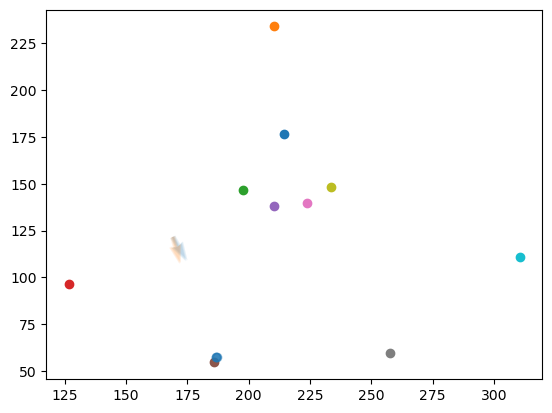

In [334]:
fig, ax = plt.subplots()

for key in nodes:
     node = nodes[key]
     for n in node:
         ax.scatter(n[0],n[1])
ax.scatter(max_posterior_2d[::10,0] + np.random.rand(len(max_posterior_2d[::10,0]))*.1,
            max_posterior_2d[::10,1] + + np.random.rand(len(max_posterior_2d[::10,0]))*.1, alpha = 0.5)

ax.quiver(animal_location[::10,0],animal_location[::10,1],
           head_orientation_unit[::10,0],head_orientation_unit[::10,1],color = 'C0',alpha = 0.1)
ax.quiver(animal_location[::10,0],animal_location[::10,1],
           displacement_unit[::10,0],displacement_unit[::10,1],color = 'C1',alpha = 0.1)


# Invert the y-axis (make it upside down)
#ax.invert_yaxis()

array([225.12560103, 136.2734064 ])

In [ ]:
#plt.plot(max_posterior_1d)
for key in nodes:
    node = nodes[key]
    for n in node:
        plt.scatter(n[0],n[1])
plt.scatter(max_posterior_2d[:,0], max_posterior_2d[:,1])